In [1]:
import yfinance as yf
import pandas as pd
from statsmodels.tsa.stattools import adfuller

## Data collection 

In [2]:
tickers="AAPL, MSFT, AMZN, NVDA, GOOGL, GOOG, META, TSLA, BRK-B, UNH, JNJ, JPM, V, PG, XOM, HD, MA, CVX, MRK, ABBV, AVGO, COST, KO, PEP, WMT, BAC, CRM, DIS, ORCL, TMO, ACN, NFLX, LIN, ABT, MCD, CSCO, DHR, VZ, WFC, INTU, CMCSA, ADP, TXN, IBM, PM, NKE, RTX, HON, QCOM, UPS, LOW, BMY, AMGN, SPGI, SCHW, CAT, GS, BLK, MDLZ, CVS, AXP, DE, MS, AMT, C, BA, T, ISRG, NOW, GILD, LMT, ADI, MMM, MO, SYK, ZTS, CB, TJX, ETN, CI, SO, VRTX, PGR, MU, PLD, REGN, USB, WM, BK, KLAC, LRCX, FIS, ICE, APD, HCA, SHW, EL, NOC"
tickers_list = tickers.split(", ")

In [3]:
df = yf.download(
    tickers,
    start="2018-01-01",
    interval="1d",
    auto_adjust=True,
    group_by="tickers",
    threads=True
)

[*********************100%***********************]  98 of 98 completed


In [4]:
df.shape

(2094, 490)

In [5]:
df.head()

Ticker            FIS                                                   SO  \
Price            Open       High        Low      Close   Volume       Open   
Date                                                                         
2018-01-02  80.936426  81.202471  80.026740  80.412926  1231700  34.289202   
2018-01-03  80.361418  81.056555  80.301345  80.884918  1370600  33.603559   
2018-01-04  80.953587  82.017748  80.953587  81.485664  1673900  33.489291   
2018-01-05  81.648730  81.949097  81.039411  81.949097  1721000  33.417872   
2018-01-08  81.854679  82.687129  81.580056  82.155052  1185900  33.496427   

Ticker                                                ...       GOOG  \
Price            High        Low      Close   Volume  ...       Open   
Date                                                  ...              
2018-01-02  34.332056  33.539283  33.689266  7278800  ...  51.990163   
2018-01-03  33.832106  33.453576  33.496429  6292800  ...  52.782159   
2018-01-04  33.632133  33.267888  33.353592  5231500  ...  53.957017   
2018-01-05  33.532146  33.167897  33.410728  6120500  ...  54.254575   
2018-01-08  33.732115  33.375010  33.710690  7945500  ...  54.662719   

Ticker                                                       WMT             \
Price            High        Low      Close    Volume       Open       High   
Date                                                                          
2018-01-02  52.912590  51.835930  52.816380  24752000  29.063001  29.206414   
2018-01-03  53.872209  52.727607  53.683262  28604000  28.931293  29.267872   
2018-01-04  54.233249  53.758743  53.877666  20092000  29.133247  29.203489   
2018-01-05  54.762903  54.155387  54.662724  25582000  29.162508  29.379090   
2018-01-08  55.111038  54.632468  54.896301  20952000  29.341053  29.780071   

Ticker                                      
Price             Low      Close    Volume  
Date                                        
2018-01-02  28.834713  28.855202  30451500  
2018-01-03  28.907877  29.106901  26710800  
2018-01-04  28.948861  29.133247  20491200  
2018-01-05  29.153730  29.305922  21852000  
2018-01-08  29.329343  29.739094  26531700  

[5 rows x 490 columns]

## Data Cleaning 

In [6]:
df = df.xs("Close", axis=1, level=1).pct_change().dropna()
df=pd.DataFrame(df)
df.head()

Ticker,FIS,SO,AMT,CI,BRK-B,DIS,KO,T,ORCL,AMZN,...,ABT,LOW,GS,DHR,LIN,HCA,APD,CSCO,GOOG,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-03,0.005870,-0.005724,0.003897,0.016785,0.013031,0.004293,-0.002196,-0.023093,0.023161,0.012775,...,0.002211,0.004366,-0.009309,0.013306,0.008388,-0.027594,0.005438,0.007977,0.016413,0.008723
2018-01-04,0.007427,-0.004264,-0.014611,0.005244,0.004505,-0.000445,0.014085,0.009296,0.009851,0.004476,...,-0.001697,0.007824,0.013976,0.004804,0.015683,-0.012408,0.003846,0.002829,0.003621,0.000905
2018-01-05,0.005687,0.001713,0.006446,0.016953,0.003637,-0.005435,-0.000218,0.003684,0.006019,0.016163,...,0.002890,0.021566,-0.005100,0.006269,0.008751,0.011284,0.008381,0.013849,0.014571,0.005927
2018-01-08,0.002513,0.008978,0.010675,-0.011066,0.006554,-0.014335,-0.001519,0.002884,0.010522,0.014425,...,-0.002882,-0.010872,-0.014520,0.005702,-0.000372,-0.002070,0.001069,0.010372,0.004273,0.014781
2018-01-09,0.003238,-0.012500,-0.006759,-0.001681,0.001381,-0.000727,0.005000,-0.002607,0.005534,0.004676,...,0.001700,0.008964,0.008459,0.035275,0.009733,-0.008646,0.002550,-0.006260,-0.000614,-0.012007


#### Row Return to Log Return

In [7]:
import numpy as np
returns = np.log(1+df)
returns.head()

Ticker,FIS,SO,AMT,CI,BRK-B,DIS,KO,T,ORCL,AMZN,...,ABT,LOW,GS,DHR,LIN,HCA,APD,CSCO,GOOG,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-03,0.005852,-0.005740,0.003890,0.016646,0.012947,0.004284,-0.002198,-0.023364,0.022897,0.012694,...,0.002209,0.004357,-0.009352,0.013218,0.008353,-0.027982,0.005423,0.007946,0.016280,0.008685
2018-01-04,0.007400,-0.004273,-0.014719,0.005230,0.004495,-0.000445,0.013987,0.009253,0.009803,0.004466,...,-0.001699,0.007794,0.013879,0.004792,0.015561,-0.012486,0.003839,0.002825,0.003615,0.000905
2018-01-05,0.005671,0.001712,0.006426,0.016811,0.003631,-0.005450,-0.000218,0.003678,0.006001,0.016033,...,0.002886,0.021337,-0.005114,0.006249,0.008713,0.011221,0.008346,0.013754,0.014466,0.005910
2018-01-08,0.002510,0.008938,0.010619,-0.011128,0.006532,-0.014438,-0.001520,0.002880,0.010467,0.014322,...,-0.002886,-0.010931,-0.014626,0.005686,-0.000372,-0.002072,0.001068,0.010319,0.004264,0.014673
2018-01-09,0.003233,-0.012579,-0.006782,-0.001682,0.001380,-0.000727,0.004988,-0.002611,0.005519,0.004665,...,0.001699,0.008924,0.008423,0.034667,0.009686,-0.008683,0.002547,-0.006279,-0.000614,-0.012079


#### Average Correlation between  the selected assets

In [8]:
returns.corr().mean().mean()

np.float64(0.3849841060271267)

## Checking the stationarity

In [9]:
results = returns.apply(lambda col: adfuller(col)[1])  # Extract p-values for each asset's returns
results = pd.Series(results, index=returns.columns)
results.max()

np.float64(2.6817937664339188e-14)

## PCA application

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [11]:
scaler = StandardScaler()
returns_scaled = scaler.fit_transform(returns)

In [12]:
pca = PCA()
pca.fit(returns_scaled)

PCA()

In [13]:
eigenvalues      = pd.Series(pca.explained_variance_)          # variance of each PC
eigenvectors     = pd.DataFrame(pca.components_)                  # shape: (N_components, N_assets)
explained_ratio  = pd.Series(pca.explained_variance_ratio_)    # % variance per PC
cumulative_var   = np.cumsum(explained_ratio)

In [14]:
eigenvalues.head()

0    38.709707
1     6.334331
2     4.700880
3     2.199786
4     1.844059
dtype: float64

In [15]:
eigenvectors.head()

,0,1,2,3,4,5,6,7,8,9,...,88,89,90,91,92,93,94,95,96,97
0,0.101386,0.085208,0.086286,0.086436,0.130327,0.104913,0.099440,0.082274,0.080495,0.089706,...,0.101631,0.110381,0.122676,0.102609,0.118589,0.093067,0.105619,0.111957,0.103890,0.072439
1,0.005405,-0.183605,-0.104333,-0.106655,-0.070366,0.033682,-0.177973,-0.154870,0.084524,0.195089,...,-0.053899,0.006755,0.033093,0.027580,-0.024073,-0.049985,-0.047061,0.024699,0.157780,-0.063309
2,-0.008598,-0.084870,-0.145224,0.007538,0.080139,0.079704,-0.065438,0.027225,-0.005391,-0.091734,...,-0.144937,-0.030649,0.185338,-0.133383,-0.007770,0.038758,-0.015694,-0.016684,-0.065689,-0.107606
3,-0.148052,-0.083371,-0.131816,0.051925,-0.015912,-0.090554,-0.081169,-0.009412,0.010220,-0.043816,...,0.022746,-0.036900,0.027035,0.057410,-0.029550,-0.046813,0.008331,0.078558,-0.018988,0.033297
4,-0.123556,0.128330,0.084040,-0.076065,-0.045867,-0.005270,0.147007,0.005511,0.007781,-0.034501,...,-0.113953,0.147355,-0.047298,-0.129254,0.033611,0.039861,0.056995,0.004743,-0.046790,0.167676


In [16]:
explained_ratio

0     0.394808
1     0.064605
2     0.047945
3     0.022436
4     0.018808
        ...   
93    0.001176
94    0.000982
95    0.000927
96    0.000850
97    0.000040
Length: 98, dtype: float64

In [17]:
cumulative_var.tail()

93    0.997200
94    0.998183
95    0.999110
96    0.999960
97    1.000000
dtype: float64

## The Marchenko-Pastur filter 

In [18]:
T, N = returns_scaled.shape
lambda_noise = (1 + np.sqrt(N / T))**2
signal_eigenvalues  = eigenvalues[eigenvalues.values > lambda_noise].reset_index(drop=True)
signal_eigenvectors = eigenvectors[eigenvalues.values > lambda_noise]  # shape: (n_signal, N_assets)
n_signal = np.sum(eigenvalues.values > lambda_noise)
print(f"T={T}, N={N}")
print(f"Noise threshold (lambda_max): {lambda_noise:.4f}")
print(f"Signal PCs: {n_signal}")

T=2093, N=98
Noise threshold (lambda_max): 1.4796
Signal PCs: 7


## Equal weighted Portfolio 

#### Construction

In [19]:
N = returns.shape[1]
weights = np.ones(N) / N
weights

array([0.01020408, 0.01020408, 0.01020408, 0.01020408, 0.01020408,
       0.01020408, 0.01020408, 0.01020408, 0.01020408, 0.01020408,
       0.01020408, 0.01020408, 0.01020408, 0.01020408, 0.01020408,
       0.01020408, 0.01020408, 0.01020408, 0.01020408, 0.01020408,
       0.01020408, 0.01020408, 0.01020408, 0.01020408, 0.01020408,
       0.01020408, 0.01020408, 0.01020408, 0.01020408, 0.01020408,
       0.01020408, 0.01020408, 0.01020408, 0.01020408, 0.01020408,
       0.01020408, 0.01020408, 0.01020408, 0.01020408, 0.01020408,
       0.01020408, 0.01020408, 0.01020408, 0.01020408, 0.01020408,
       0.01020408, 0.01020408, 0.01020408, 0.01020408, 0.01020408,
       0.01020408, 0.01020408, 0.01020408, 0.01020408, 0.01020408,
       0.01020408, 0.01020408, 0.01020408, 0.01020408, 0.01020408,
       0.01020408, 0.01020408, 0.01020408, 0.01020408, 0.01020408,
       0.01020408, 0.01020408, 0.01020408, 0.01020408, 0.01020408,
       0.01020408, 0.01020408, 0.01020408, 0.01020408, 0.01020

In [20]:
portfolio_returns = returns @ weights
portfolio_returns.columns = ['Returns']
portfolio_returns.describe()

count    2093.000000
mean        0.000494
std         0.011865
min        -0.131752
25%        -0.004241
50%         0.000725
75%         0.006090
max         0.097721
dtype: float64

<Axes: title={'center': 'Equal-Weighted Portfolio Returns'}, xlabel='Date'>

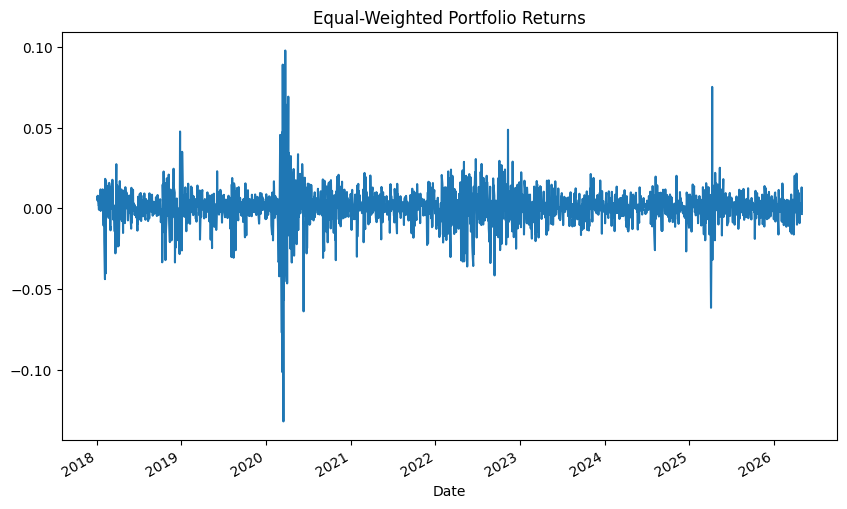

In [21]:
portfolio_returns.plot(title='Equal-Weighted Portfolio Returns', figsize=(10,6))

<Axes: title={'center': 'Cumulative Returns of Equal-Weighted Portfolio'}, xlabel='Date'>

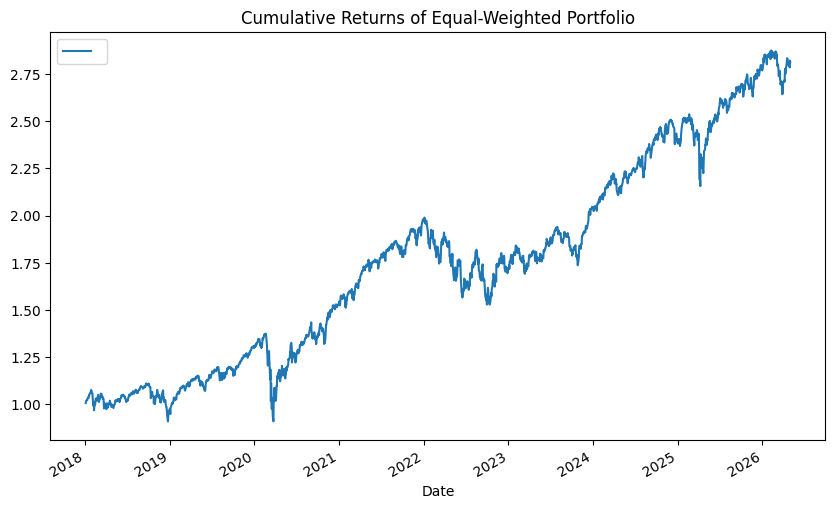

In [22]:
cum_returns = np.exp(portfolio_returns.cumsum()) # cumulative product of (1 + returns) to get wealth index
cum_returns.plot(title='Cumulative Returns of Equal-Weighted Portfolio', figsize=(10,6),legend=True)

#### Maximum Drawdown / Sharp ratio

In [52]:
wealth_index=cum_returns
previous_peak = wealth_index.cummax()

<Axes: title={'center': 'Wealth Index and Drawdown'}, xlabel='Date'>

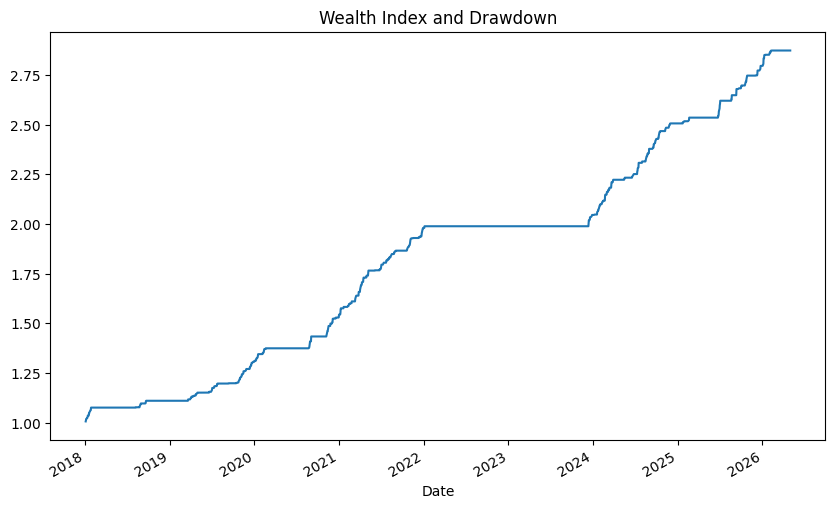

In [53]:
previous_peak.plot(title='Wealth Index and Drawdown', figsize=(10,6), label='Wealth Index')

In [54]:
drawdown = (wealth_index - previous_peak) / previous_peak
print('Max drawdown of', drawdown.min())

Max drawdown of -0.33785543732989787


<Axes: title={'center': 'Drawdown'}, xlabel='Date'>

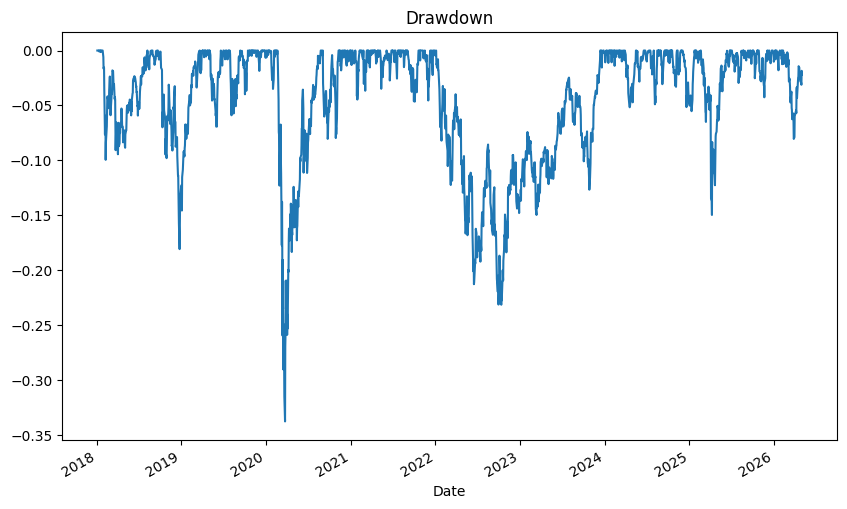

In [55]:
drawdown.plot(title="Drawdown", figsize=(10,6))

In [57]:
mean_return = portfolio_returns.mean()
std_return = portfolio_returns.std()
sharpe = (mean_return / std_return) * np.sqrt(252)
sharpe

np.float64(0.6606310844976784)

#### E-Q Portfolio risk exposure 

In [23]:
pc_exposure = signal_eigenvectors @ weights
variance_contrib = (pc_exposure**2) * signal_eigenvalues
variance_contrib = variance_contrib / variance_contrib.sum()
variance_contrib*100

0    99.872149
1     0.026965
2     0.063500
3     0.018259
4     0.000030
5     0.018763
6     0.000334
dtype: float64

In [24]:
p   = variance_contrib
ENB = np.exp(-np.sum(p * np.log(p + 1e-10))) # add small constant to avoid log(0)

In [25]:
print(f"Assets in portfolio      : {N}")
print(f"Signal PCs (real factors): {n_signal}")
print(f"Effective Number of Bets : {ENB:.2f}")
print(f"Diversification Ratio    : {ENB / N * 100:.2f}%")
print(f"")
print(f"Interpretation: your {N}-asset portfolio")
print(f"behaves like {ENB:.1f} independent bets")
print(f"out of a possible {N}")

Assets in portfolio      : 98
Signal PCs (real factors): 7
Effective Number of Bets : 1.01
Diversification Ratio    : 1.03%

Interpretation: your 98-asset portfolio
behaves like 1.0 independent bets
out of a possible 98


## interpretation of the 7 real factors

In [26]:
tickers = list(returns.columns)

loadings = pd.DataFrame(
    signal_eigenvectors.values,
    index   = [f'PC{i}' for i in range(n_signal)],
    columns = tickers
)
loadings

,FIS,SO,AMT,CI,BRK-B,DIS,KO,T,ORCL,AMZN,...,ABT,LOW,GS,DHR,LIN,HCA,APD,CSCO,GOOG,WMT
PC0,0.101386,0.085208,0.086286,0.086436,0.130327,0.104913,0.099440,0.082274,0.080495,0.089706,...,0.101631,0.110381,0.122676,0.102609,0.118589,0.093067,0.105619,0.111957,0.103890,0.072439
PC1,0.005405,-0.183605,-0.104333,-0.106655,-0.070366,0.033682,-0.177973,-0.154870,0.084524,0.195089,...,-0.053899,0.006755,0.033093,0.027580,-0.024073,-0.049985,-0.047061,0.024699,0.157780,-0.063309
PC2,-0.008598,-0.084870,-0.145224,0.007538,0.080139,0.079704,-0.065438,0.027225,-0.005391,-0.091734,...,-0.144937,-0.030649,0.185338,-0.133383,-0.007770,0.038758,-0.015694,-0.016684,-0.065689,-0.107606
PC3,-0.148052,-0.083371,-0.131816,0.051925,-0.015912,-0.090554,-0.081169,-0.009412,0.010220,-0.043816,...,0.022746,-0.036900,0.027035,0.057410,-0.029550,-0.046813,0.008331,0.078558,-0.018988,0.033297
PC4,-0.123556,0.128330,0.084040,-0.076065,-0.045867,-0.005270,0.147007,0.005511,0.007781,-0.034501,...,-0.113953,0.147355,-0.047298,-0.129254,0.033611,0.039861,0.056995,0.004743,-0.046790,0.167676
PC5,-0.059379,-0.005164,-0.146636,0.122935,0.053509,-0.019328,0.037453,0.107105,0.140906,0.119601,...,-0.110116,-0.186845,-0.047503,-0.236877,-0.038604,-0.074086,-0.071535,0.094797,0.145821,0.126214
PC6,-0.032557,-0.011017,-0.020071,0.148148,-0.051221,-0.102572,-0.039627,-0.213751,0.001748,-0.139813,...,0.045133,0.021989,-0.098105,0.089026,0.041079,0.152246,0.013634,-0.044383,-0.105554,-0.202344


In [38]:
pc_labels = {
    'PC0': 'Market Beta',
    'PC1': 'Secular Growth vs Defensive Income',
    'PC2': 'Banking vs Quality Defensives',
    'PC3': 'Biotech vs Financial Software',
    'PC4': 'Semiconductor Equipment vs Pharma',
    'PC5': 'Defense & Media vs Precision Instruments',
    'PC6': 'Pure Defense vs Telecom'
}

for pc in loadings.index:
    row     = loadings.loc[pc]
    top_pos = row.nlargest(3)
    top_neg = row.nsmallest(3)
    label   = pc_labels[pc]

    print(f"\n{'='*55}")
    print(f"{pc} — {label}")
    print(f"{'='*55}")
    print(f"  Top positive loaders:")
    for ticker, val in top_pos.items():
        print(f"    {ticker:<10} {val:+.4f}")
    print(f"  Top negative loaders:")
    for ticker, val in top_neg.items():
        print(f"    {ticker:<10} {val:+.4f}")


PC0 — Market Beta
  Top positive loaders:
    BLK        +0.1312
    BRK-B      +0.1303
    MS         +0.1267
  Top negative loaders:
    REGN       +0.0643
    NFLX       +0.0672
    VZ         +0.0687

PC1 — Secular Growth vs Defensive Income
  Top positive loaders:
    NVDA       +0.2184
    AMZN       +0.1951
    LRCX       +0.1772
  Top negative loaders:
    SO         -0.1836
    KO         -0.1780
    VZ         -0.1734

PC2 — Banking vs Quality Defensives
  Top positive loaders:
    C          +0.2181
    WFC        +0.2181
    BAC        +0.2178
  Top negative loaders:
    PG         -0.1587
    TMO        -0.1465
    PEP        -0.1460

PC3 — Biotech vs Financial Software
  Top positive loaders:
    REGN       +0.2719
    GILD       +0.2545
    AMGN       +0.2519
  Top negative loaders:
    ICE        -0.1656
    SPGI       -0.1608
    INTU       -0.1598

PC4 — Semiconductor Equipment vs Pharma
  Top positive loaders:
    LRCX       +0.1844
    WMT        +0.1677
    PEP   

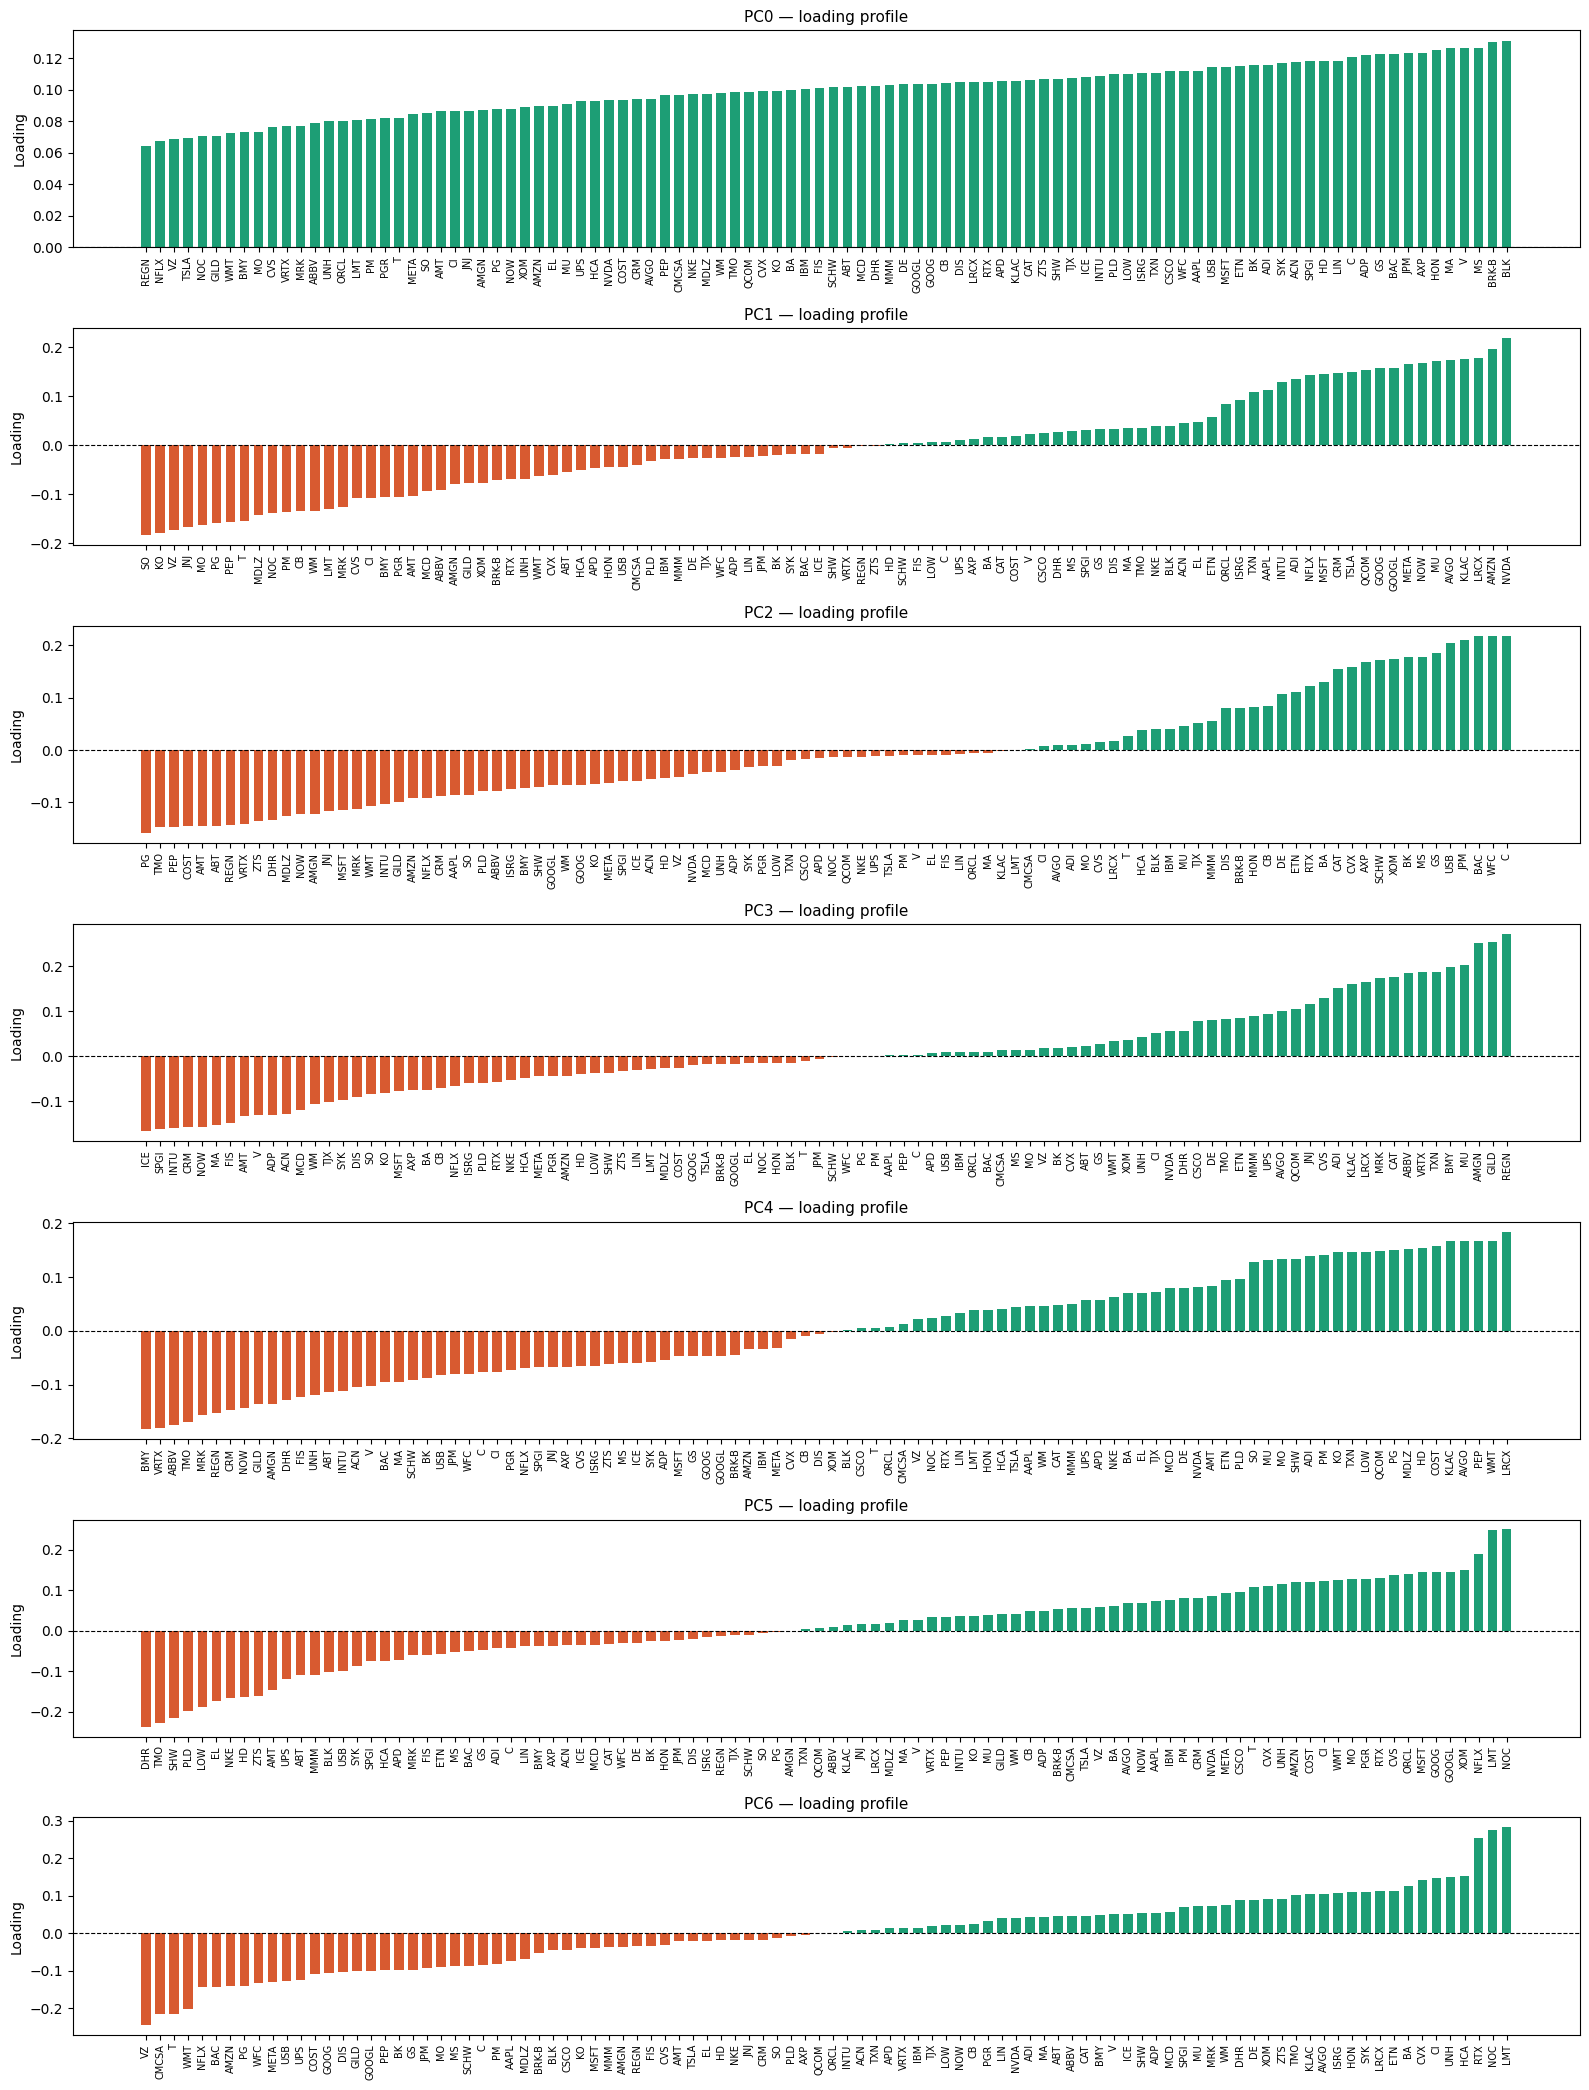

In [39]:
from matplotlib import pyplot as plt


fig, axes = plt.subplots(n_signal, 1, figsize=(16, 3 * n_signal))

for i, pc in enumerate(loadings.index):
    row    = loadings.loc[pc].sort_values()
    colors = ['#D85A30' if v < 0 else '#1D9E75' for v in row.values]
    
    axes[i].bar(row.index, row.values, color=colors, width=0.7)
    axes[i].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[i].set_title(f'{pc} — loading profile', fontsize=11)
    axes[i].set_xticks(range(len(row)))
    axes[i].set_xticklabels(row.index, rotation=90, fontsize=7)
    axes[i].set_ylabel('Loading')

plt.tight_layout()
plt.show()

#### PCs Growth 

In [51]:
# Rolling window parameters
window  = 252        # 1 trading year
step    = 21         # roll forward 1 month at a time

dates        = []
pc0_shares   = []
n_signals    = []
enbs         = []

for start in range(0, T - window, step):
    end     = start + window
    window_returns = returns_scaled[start:end, :]

    # PCA on this window
    pca_roll = PCA()
    pca_roll.fit(window_returns)

    ev_roll  = pca_roll.explained_variance_
    evec_roll = pca_roll.components_

    # Marchenko-Pastur for this window
    T_w, N_w      = window_returns.shape
    lam_noise     = (1 + np.sqrt(N_w / T_w))**2
    sig_mask      = ev_roll > lam_noise
    n_sig         = sig_mask.sum()

    sig_ev        = ev_roll[sig_mask]
    sig_evec      = evec_roll[sig_mask]

    # PC0 share of total explained variance
    pc0_share     = sig_ev[0] / sig_ev.sum()

    # ENB of equal-weighted portfolio in this window
    betas_roll    = sig_evec @ weights
    rc_roll       = (betas_roll**2) * sig_ev
    p_roll        = rc_roll / rc_roll.sum()
    enb_roll      = np.exp(-np.sum(p_roll * np.log(p_roll + 1e-10)))

    # Record date at end of window
    dates.append(returns.index[end - 1])
    pc0_shares.append(pc0_share)
    n_signals.append(n_sig)
    enbs.append(enb_roll)

# Build results DataFrame
roll_df = pd.DataFrame({
    'PC0_share' : pc0_shares,
    'N_signal'  : n_signals,
    'ENB'       : enbs
}, index=dates)

print(roll_df.describe().round(4))

       PC0_share  N_signal      ENB
count    88.0000   88.0000  88.0000
mean      0.6864    4.0227   1.0944
std       0.1093    1.3977   0.0902
min       0.4164    2.0000   1.0022
25%       0.5926    3.0000   1.0350
50%       0.6878    4.0000   1.0633
75%       0.7888    5.0000   1.1354
max       0.8741    7.0000   1.4368


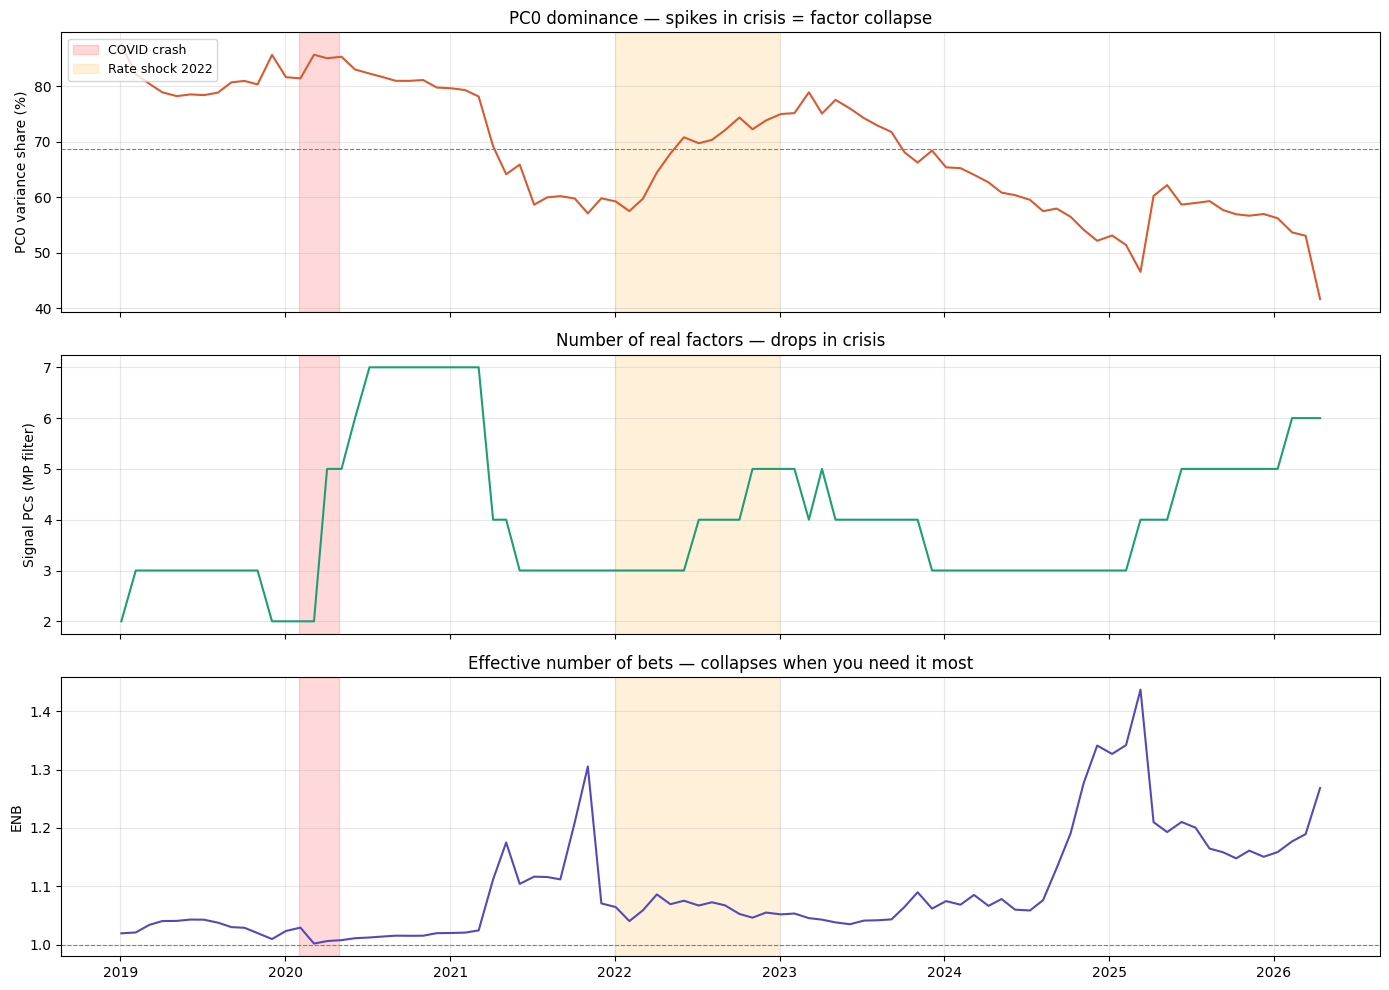

In [42]:
# Plot all three rolling metrics
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel 1 — PC0 dominance over time
axes[0].plot(roll_df.index, roll_df['PC0_share'] * 100,
             color='#D85A30', linewidth=1.5)
axes[0].axhline(roll_df['PC0_share'].mean() * 100,
                linestyle='--', color='gray', linewidth=0.8)
axes[0].set_ylabel('PC0 variance share (%)')
axes[0].set_title('PC0 dominance — spikes in crisis = factor collapse')
axes[0].grid(True, alpha=0.3)

# Mark crisis periods
for ax in axes:
    ax.axvspan(pd.Timestamp('2020-02-01'),
               pd.Timestamp('2020-04-30'),
               alpha=0.15, color='red', label='COVID crash')
    ax.axvspan(pd.Timestamp('2022-01-01'),
               pd.Timestamp('2022-12-31'),
               alpha=0.15, color='orange', label='Rate shock 2022')

# Panel 2 — number of signal PCs over time
axes[1].plot(roll_df.index, roll_df['N_signal'],
             color='#1D9E75', linewidth=1.5)
axes[1].set_ylabel('Signal PCs (MP filter)')
axes[1].set_title('Number of real factors — drops in crisis')
axes[1].grid(True, alpha=0.3)

# Panel 3 — rolling ENB
axes[2].plot(roll_df.index, roll_df['ENB'],
             color='#534AB7', linewidth=1.5)
axes[2].axhline(1.0, linestyle='--', color='gray', linewidth=0.8)
axes[2].set_ylabel('ENB')
axes[2].set_title('Effective number of bets — collapses when you need it most')
axes[2].grid(True, alpha=0.3)

axes[0].legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## Maximum Drawdown / Sharp ratio

## Benckmark

In [34]:
ticker=yf.Ticker("^GSPC")
sp500 = ticker.history(start="2018-01-01")

In [35]:
sp500 = sp500['Close'].pct_change().dropna()
sp500 = sp500.rename('returns')

In [36]:
sp500_r=(1+sp500).cumprod() 
sp500_r=pd.DataFrame(sp500_r)
sp500_r.index=pd.to_datetime(sp500_r.index, format="%D/%m/%Y").to_period('D')

C:\Users\PC\AppData\Local\Temp\ipykernel_252012\373091507.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  sp500_r.index=pd.to_datetime(sp500_r.index, format="%D/%m/%Y").to_period('D')


In [37]:
excess_returns = sp500_r['returns'].iloc[-1] - cum_returns.iloc[-1]
excess_returns

np.float64(-0.12870177656358228)